# Bike Sharing Demand Prediction (Regression)

#### Contents

1. Business Problem & Data Understanding
2. Data Cleaning, Feature Selection, & Feature Engineering
3. Analytics (Algorithm, Evaluation Metrics)
4. Conclusion and Recommendation/Improvement

***

## 1. Business Problem & Data Understanding

### 1.1 Business Problem Understanding

**Context**

Sistem berbagi sepeda merupakan generasi baru dari penyewaan sepeda tradisional, di mana seluruh prosesnya—mulai dari pendaftaran keanggotaan, penyewaan, hingga pengembalian—telah menjadi otomatis. Melalui sistem ini, pengguna dapat dengan mudah menyewa sepeda dari satu lokasi dan mengembalikannya di lokasi lain. Saat ini, terdapat lebih dari 500 program berbagi sepeda di seluruh dunia yang terdiri dari lebih dari 500 ribu unit sepeda. Saat ini, sistem ini menarik minat yang besar karena perannya yang penting dalam masalah lalu lintas, lingkungan, dan kesehatan.

Selain aplikasi dunia nyata yang menarik dari sistem berbagi sepeda, karakteristik data yang dihasilkan oleh sistem ini menjadikannya menarik untuk penelitian. Tidak seperti layanan transportasi lain seperti bus atau kereta bawah tanah, durasi perjalanan, titik keberangkatan, dan titik kedatangan dicatat secara eksplisit dalam sistem ini. Fitur ini mengubah sistem berbagi sepeda menjadi jaringan sensor virtual yang dapat digunakan untuk mendeteksi mobilitas di kota. Oleh karena itu, diharapkan peristiwa-peristiwa terpenting di kota dapat dideteksi dengan memantau data ini.

**Stakeholder dan Waktu Penggunaan Model**
- **Stakeholder utama:** tim operasional bike sharing (perencana alokasi unit dan penjadwalan staf).
- **Waktu penggunaan model:** sebelum operasional harian/shift berjalan, untuk memprediksi demand berdasarkan kondisi jam, musim, hari libur, dan cuaca.

**Problem Statement**
Permintaan penyewaan sepeda berfluktuasi tajam berdasarkan jam, musim, hari libur, dan kondisi cuaca. Tim operasional menghadapi dua risiko utama:
- Kekurangan unit pada jam/kondisi dengan permintaan tinggi.
- Kelebihan unit pada saat permintaan rendah.

Dampak bisnis yang diukur: semakin besar error prediksi, semakin tinggi risiko salah alokasi unit dan inefisiensi operasional.

**Goals (Specific, Measurable, Achievable)**
Membangun model machine learning regresi untuk memprediksi jumlah rental sepeda secara akurat dan stabil agar perencanaan operasional lebih tepat.

Target evaluasi model pada data uji:
- Menekan nilai **MAE** (Mean Absolute Error) dan **RMSE** (Root Mean Squared Error) serendah mungkin.
- Menjaga **R-squared** tetap tinggi agar variasi demand dapat dijelaskan model dengan baik.

notes*
1. MAE (Mean Absolute Error)
Mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual.
2. RMSE (Root Mean Squared Error)
Mengukur error dengan memberi penalti lebih besar ke error besar.
3. R-squared (R²)
Mengukur seberapa baik model menjelaskan variasi data.

### 1.2 Data Understanding

**Ringkasan Dataset**

| Komponen | Keterangan |
|---|---|
| Nama dataset | Bike Sharing Dataset |
| Jumlah baris | 12,165 |
| Jumlah kolom | 11 |
| Target kolom | `cnt` (total rental sepeda) |
| Tipe problem | Regresi |


**Data Dictionary**

| Kolom | Deskripsi |
|---|---|
| `dteday` | Tanggal |
| `season` | Musim (1: winter, 2: spring, 3: summer, 4: fall) 
| `hr` | Jam (0-23) | 
| `holiday` | Hari libur (0/1) | 
| `temp` | Suhu ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-8, tmax=39 | 
| `atemp` | Suhu terasa ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-16, tmax=50 |
| `hum` | Kelembapan ternormalisasi (dibagi 100) |
| `weathersit` | Kategori cuaca 1-4 |
| `casual` | Jumlah pengguna kasual |
| `registered` | Jumlah pengguna terdaftar | 
| `cnt` | Total rental (`casual + registered`) 

- baris merepresentasikan kondisi sewa sepeda pada waktu tertentu
- kolom merepresentasikan faktor waktu, cuaca, dan komponen penyusun jumlah rental.

**Mapping `weathersit`**
- 1: Clear, Few clouds, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

*Catatan: karena `cnt = casual + registered`, kolom `casual` dan `registered` tidak digunakan sebagai prediktor pada modeling untuk menghindari data leakage.*



In [1]:
# Import library untuk analisis data dan visualisasi
import pandas as pd # untuk manipulasi data
import numpy as np # untuk operasi numerik
import matplotlib.pyplot as plt # untuk visualisasi data
import seaborn as sns # untuk visualisasi data
import gdown # untuk download dari Google Drive

import warnings
warnings.filterwarnings('ignore') # untuk mengabaikan peringatan


In [2]:
# Load datasaet dari Google Drive https://drive.google.com/uc?id=1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP
!pip -q install gdown

file_id = "1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP"
output_file = "data.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

df = pd.read_csv(output_file)

print("\n=== Jumlah Baris dan Kolom  ===")
print("Jumlah Baris:", df.shape[0])
print("Jumlah Kolom:", df.shape[1])
print("\n=== Data Preview (Top 5) ===")
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP
To: /content/data.csv
100%|██████████| 568k/568k [00:00<00:00, 95.0MB/s]


=== Jumlah Baris dan Kolom  ===
Jumlah Baris: 12165
Jumlah Kolom: 11

=== Data Preview (Top 5) ===


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


## 2. Data Cleaning, Feature Selection, & Feature Engineering

### 2.1 Data Cleaning

Tahap ini memastikan data bersih dan siap untuk proses analitik melalui tiga pemeriksaan berikut:
- **Column Profiling Table** untuk melihat struktur kolom (tipe data, jumlah nilai unik, dan contoh nilai).
- **Missing Value and Duplicate Check** untuk memeriksa nilai hilang dan baris duplikat.
- **Descriptive Statistics** rangkuman statistik data.

In [3]:
summary_table = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'n_unique': df.nunique(dropna=False).values,
    'sample_value': [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

print("\n=== Column Profiling Table ===")
display(summary_table)

print("\n=== Missing Value ===")
missing_check = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values
})
display(missing_check)

print("\n=== Duplicate Check ===")
print("Duplicate rows:", df.duplicated().sum())

print("\n=== Descriptive Statistics ===")
display(df.describe().T)


=== Column Profiling Table ===


,column,dtype,n_unique,sample_value
0,dteday,object,731,2011-12-09
1,hum,float64,89,0.62
2,weathersit,int64,4,1
3,holiday,int64,2,0
4,season,int64,4,4
5,atemp,float64,65,0.3485
6,temp,float64,50,0.36
7,hr,int64,24,16
8,casual,int64,305,24
9,registered,int64,742,226



=== Missing Value ===


,column,missing_count,missing_pct
0,dteday,0,0.0
1,hum,0,0.0
2,weathersit,0,0.0
3,holiday,0,0.0
4,season,0,0.0
5,atemp,0,0.0
6,temp,0,0.0
7,hr,0,0.0
8,casual,0,0.0
9,registered,0,0.0



=== Duplicate Check ===
Duplicate rows: 0

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
hum,12165.0,0.625451,0.192102,0.00,0.4700,0.6200,0.7800,1.0
weathersit,12165.0,1.416934,0.635937,1.00,1.0000,1.0000,2.0000,4.0
holiday,12165.0,0.029758,0.169925,0.00,0.0000,0.0000,0.0000,1.0
season,12165.0,2.488615,1.106157,1.00,2.0000,2.0000,3.0000,4.0
atemp,12165.0,0.476996,0.171857,0.00,0.3333,0.4848,0.6212,1.0
temp,12165.0,0.498185,0.192492,0.02,0.3400,0.5000,0.6600,1.0
hr,12165.0,11.519770,6.931872,0.00,6.0000,12.0000,18.0000,23.0
casual,12165.0,35.834443,49.489286,0.00,4.0000,17.0000,49.0000,362.0
registered,12165.0,153.436580,151.046123,0.00,34.0000,115.0000,220.0000,876.0
cnt,12165.0,189.271023,181.223903,1.00,40.0000,142.0000,282.0000,970.0


- Karena tidak ada nya duplikasi baris dan data yang kosong artinya tidak perlu ada data yang harus di bersihkan

### 2.2 Feature Selection

Bagian ini digunakan untuk memahami pola data yang mendukung keputusan feature selection.

Fokus analisis:
- Distribusi target jumlah rental sepeda `(cnt)`.
- Korelasi kolom numerik.
- Pola rata-rata (Average) permintaan berdasarkan  :
  - jam (`hr`)
  -  musim (`season`)
  - cuaca (`weathersit`).

=== Distribusi Target 'cnt' ===


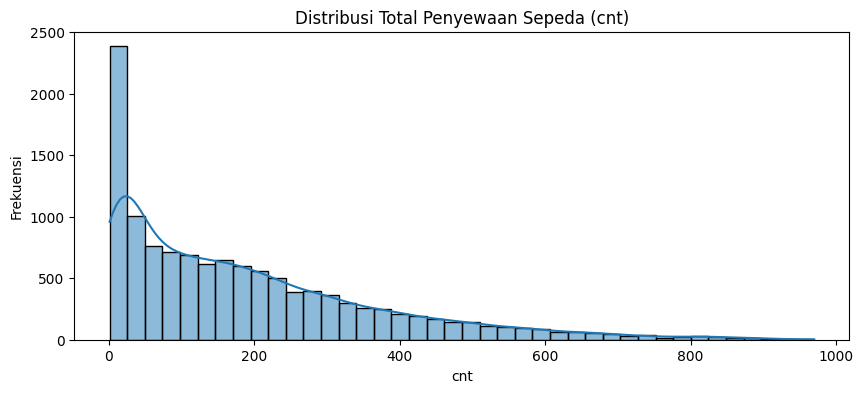

In [4]:
# Distribusi target 'cnt' 
# Histrogram
print("=== Distribusi Target 'cnt' ===")
plt.figure(figsize=(10, 4))
sns.histplot(df['cnt'], bins=40, kde=True)
plt.title('Distribusi Total Penyewaan Sepeda (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frekuensi')
plt.show()


- Sebaran nilai `cnt` tidak sepenuhnya simetris dan cenderung berkumpul pada rentang tertentu.
- Terdapat sebagian observasi dengan nilai `cnt` tinggi, sehingga distribusi menunjukkan indikasi kemencengan (skewness).
- Pola ini menandakan bahwa model perlu mampu menangani variasi demand dari kondisi normal hingga puncak permintaan.

=== Matriks Korelasi Kolom Numerik ===


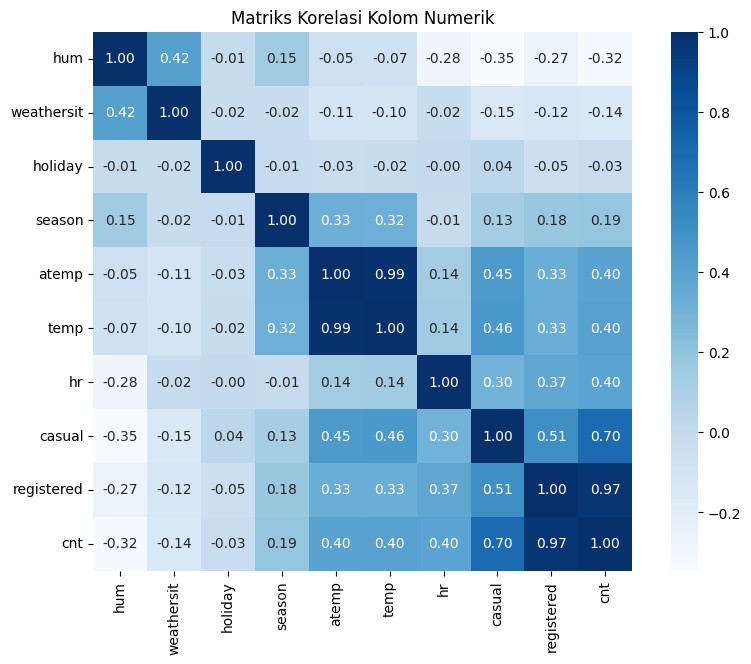

In [5]:
# Korelasi kolom numerik
print("=== Matriks Korelasi Kolom Numerik ===")
# hanya kolom numerik
num_cols = df.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Matriks Korelasi Kolom Numerik')
plt.show()


- Kolom pembentuk target (`casual`, `registered`) memiliki korelasi sangat tinggi terhadap target (`cnt`) karena secara definisi **`cnt = casual + registered`**. Karena keduanya adalah komponen pembentuk target, kolom ini termasuk **data leakage** dan tidak dipakai sebagai fitur model agar evaluasi tetap adil dan realistis.
- Kolom suhu (`temp`, `atemp`) cenderung berkorelasi positif terhadap target (`cnt`). Artinya, saat suhu lebih nyaman, jumlah penyewaan sepeda cenderung meningkat.
- Kolom kelembapan (`hum`) serta kategori cuaca (`weathersit`) cenderung berkorelasi negatif terhadap target (`cnt`). Artinya, ketika udara lebih lembap atau cuaca memburuk, permintaan sewa biasanya menurun.
- Secara keseluruhan, pola korelasi ini mendukung bahwa fitur waktu (`hr`, `season`) dan fitur cuaca (`temp`, `atemp`, `hum`, `weathersit`) merupakan prediktor utama yang relevan untuk memodelkan permintaan rental sepeda (`cnt`).

=== Average Permintaan cnt by Jam (hr) ===


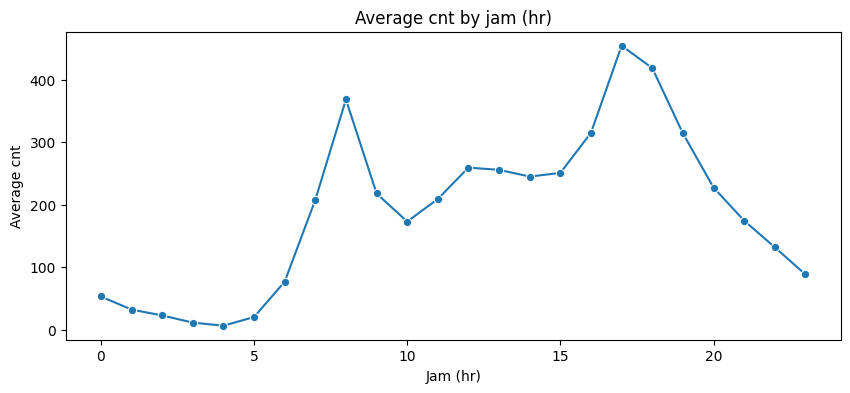

=== Top 3 Jam Tersibuk (rata-rata cnt tertinggi) ===
 hr        cnt
 17 454.276596
 18 418.564706
  8 368.312500

=== Top 3 Jam Paling Tidak Sibuk (rata-rata cnt terendah) ===
 hr       cnt
  4  6.318841
  3 11.320248
  5 20.215649


In [6]:
print("=== Average Permintaan cnt by Jam (hr) ===")

plt.figure(figsize=(10, 4))

hourly_pattern = df.groupby('hr', as_index=False)['cnt'].mean()
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', marker='o')

plt.title('Average cnt by jam (hr)')
plt.xlabel('Jam (hr)')
plt.ylabel('Average cnt')

plt.show()

hourly_rank = df.groupby('hr', as_index=False)['cnt'].mean().sort_values('cnt', ascending=False)

print('=== Top 3 Jam Tersibuk (rata-rata cnt tertinggi) ===')
print(hourly_rank.head(3).to_string(index=False))

print('\n=== Top 3 Jam Paling Tidak Sibuk (rata-rata cnt terendah) ===')
print(hourly_rank.tail(3).sort_values('cnt').to_string(index=False))

- Permintaan meningkat pada jam sibuk mobilitas harian (pergi pulang kerja) 

=== Average Permintaan cnt by Musim (season) ===


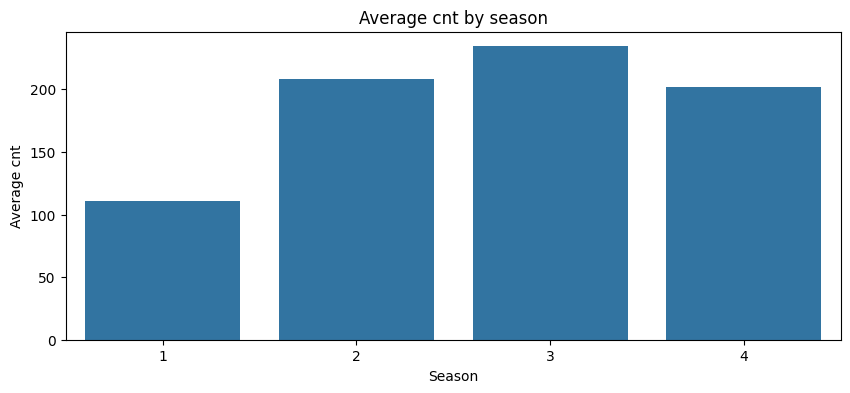


=== Ranking Musim (season)  ===
 season        cnt
      3 234.297255
      2 208.101496
      4 201.949293
      1 110.763811


In [7]:
print("=== Average Permintaan cnt by Musim (season) ===")

plt.figure(figsize=(10, 4))

seasonal_pattern = df.groupby('season', as_index=False)['cnt'].mean()
sns.barplot(data=seasonal_pattern, x='season', y='cnt')

plt.title('Average cnt by season')
plt.xlabel('Season')
plt.ylabel('Average cnt')

plt.show()

season_rank = df.groupby('season', as_index=False)['cnt'].mean().sort_values('cnt', ascending=False)

print('\n=== Ranking Musim (season)  ===')
print(season_rank.to_string(index=False))



- Terdapat gap yang cukup signifikan antara rata-rata permintaan tertinggi dan terendah, khususnya antara season 3 dan season 1. Sementara itu, gap antara season 2 dan season 4 relatif kecil, sehingga pola permintaannya cenderung mirip.

=== Average Permintaan cnt by Cuaca (weathersit) ===


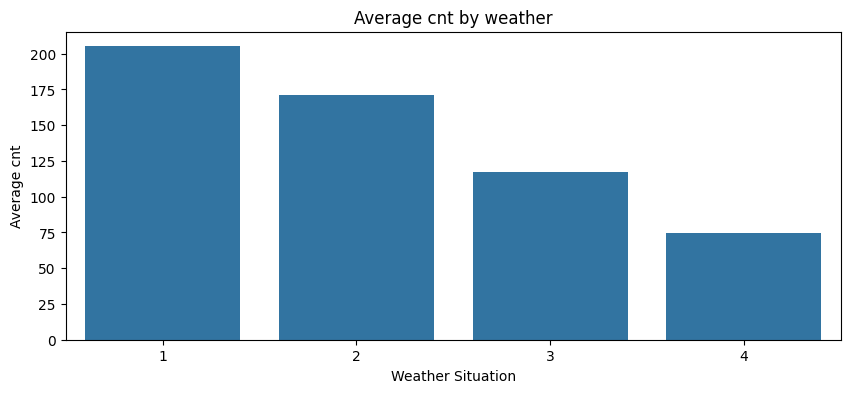


=== Ranking Cuaca (weathersit)  ===
 weathersit        cnt
          1 205.143477
          2 170.830074
          3 117.003086
          4  74.333333


In [8]:
print("=== Average Permintaan cnt by Cuaca (weathersit) ===")

plt.figure(figsize=(10, 4))

weather_pattern = df.groupby('weathersit', as_index=False)['cnt'].mean()
sns.barplot(data=weather_pattern, x='weathersit', y='cnt')

plt.title('Average cnt by weather')
plt.xlabel('Weather Situation')
plt.ylabel('Average cnt')

plt.show()

weather_rank = df.groupby('weathersit', as_index=False)['cnt'].mean().sort_values('cnt', ascending=False)

print('\n=== Ranking Cuaca (weathersit)  ===')
print(weather_rank.to_string(index=False))



- Permintaan tertinggi terjadi pada kondisi cuaca terbaik (weathersit 1) dan menurun secara konsisten hingga kondisi cuaca terburuk (weathersit 4)
- Menunjukkan adanya hubungan negatif antara tingkat keparahan cuaca dan permintaan

In [9]:
# Import library untuk preprocessing data dan modeling
from sklearn.model_selection import train_test_split, KFold, cross_validate # untuk split data dan cross-validation
from sklearn.compose import ColumnTransformer # untuk transformasi kolom spesifik
from sklearn.pipeline import Pipeline # untuk membuat pipeline preprocessing dan modeling
from sklearn.preprocessing import OneHotEncoder # untuk encoding fitur kategorikal
from sklearn.impute import SimpleImputer # untuk imputasi nilai yang hilang
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # untuk evaluasi model
from sklearn.linear_model import LinearRegression # untuk regresi linier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # untuk model 
import pickle # untuk menyimpan model

### 2.3 Feature Selection and Feature Engineering
Tahap ini menyiapkan fitur untuk model regresi : 
- Konversi tanggal
- Penghapusan fitur leakage
- Pemilihan fitur final
- Pemisahan train-test set.

In [10]:
data = df.copy()

# Konversi tanggal & ekstraksi fitur waktu
data['dteday'] = pd.to_datetime(data['dteday'])
data['year'] = data['dteday'].dt.year
data['month'] = data['dteday'].dt.month
data['dayofweek'] = data['dteday'].dt.dayofweek

# Definisi target dan fitur
target_col = 'cnt'
leakage_cols = ['casual', 'registered']
feature_cols = [c for c in data.columns if c not in [target_col, 'dteday'] + leakage_cols]

X = data[feature_cols]
y = data[target_col]

# Pemisahan fitur kategorikal & numerik
categorical_features = ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']
categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

# Split data train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== Hasil Pembagian Data ===")
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

print("\n=== Konfigurasi Fitur ===")
print('Fitur yang dihapus (data leakage):', leakage_cols)
print('Fitur numerik:', numeric_features)
print('Fitur kategorikal:', categorical_features)


=== Hasil Pembagian Data ===
Train shape: (9732, 10)
Test shape : (2433, 10)

=== Konfigurasi Fitur ===
Fitur yang dihapus (data leakage): ['casual', 'registered']
Fitur numerik: ['hum', 'atemp', 'temp']
Fitur kategorikal: ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']


- Dataset telah berhasil dipersiapkan untuk proses modeling, dengan pembagian data sebesar 80% untuk training (9732 data) dan 20% untuk testing (2433 data).
- Fitur yang berpotensi menyebabkan data leakage (casual dan registered) telah dihapus, sehingga model akan belajar secara lebih valid tanpa bias dari informasi target.
- Terdapat 3 fitur numerik  yang merepresentasikan kondisi lingkungan
  - `hum`
  - `atemp`
  - `temp`
- Terdapat 7 fitur kategorikal yang menggambarkan pola waktu dan kondisi eksternal
  - `season`
  - `weathersit`
  - `holiday`
  - `hr`
  - `year`
  - `month`
  - `dayofweek`

## 3. Analytics (Algorithm, Evaluation Metrics)

### 3.1 Algorithms Used
Model yang dibandingkan:
- Linear Regression (baseline linear).
- Random Forest Regressor (ensemble berbasis bagging, mampu menangkap hubungan non-linear).
- Gradient Boosting Regressor (ensemble boosting yang memperbaiki error secara bertahap).

### 3.2 Evaluation Metrics and Business Relevance
Metrik evaluasi yang digunakan:
- **MAE**: rata-rata error absolut (mudah diterjemahkan ke selisih unit demand).
- **RMSE**: memberi penalti lebih besar untuk error besar, relevan untuk mencegah salah prediksi ekstrem.
- **R-squared**: proporsi variasi target yang dapat dijelaskan model.

Alasan pemilihan: kombinasi MAE, RMSE, dan R-squared membantu menilai akurasi rata-rata, stabilitas terhadap outlier error, serta kemampuan model menjelaskan pola demand.

In [11]:
# Latih dan bandingkan beberapa algoritma regresi
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=250, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# Validasi silang 5-fold untuk evaluasi yang lebih stabil
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)

    rows.append({
        'model': name,
        'cv_mae': -cv_scores['test_mae'].mean(),
        'cv_rmse': -cv_scores['test_rmse'].mean(),
        'cv_r2': cv_scores['test_r2'].mean(),
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

    fitted_pipelines[name] = pipe

results = pd.DataFrame(rows).sort_values(by='test_rmse').reset_index(drop=True)
print("=== Hasil Perbandingan Model Regresi (Diurutkan berdasarkan RMSE Test) ===")
display(results)

=== Hasil Perbandingan Model Regresi (Diurutkan berdasarkan RMSE Test) ===


,model,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
0,RandomForest,38.408985,60.613357,0.888817,34.801229,56.518114,0.897505
1,GradientBoosting,63.972770,88.919806,0.761642,62.342865,88.115439,0.750867
2,LinearRegression,75.669468,101.996866,0.686314,74.788030,101.186371,0.671473


- Berdasarkan evaluasi pada validasi silang (CV) dan data test, model dengan performa terbaik adalah **RandomForest** karena memiliki **RMSE test paling rendah**.
- Nilai **MAE** yang lebih kecil menunjukkan rata-rata selisih prediksi yang lebih rendah, sedangkan **R-squared** yang tinggi menunjukkan model mampu menjelaskan variasi target (`cnt`) dengan baik.
- Secara keseluruhan, RandomForest dipilih sebagai kandidat model final karena paling seimbang dalam akurasi dan stabilitas pada tiga metrik utama: **MAE**, **RMSE**, dan **R-squared**.

In [12]:
# Pilih model final berdasarkan nilai RMSE test terendah
best_model_name = results.loc[0, 'model']
final_model = fitted_pipelines[best_model_name]

final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("=== Performa Model Final ===")
print(f'Model final: {best_model_name}')
print(f'MAE  : {final_mae:.4f}')
print(f'RMSE : {final_rmse:.4f}')
print(f'R-squared   : {final_r2:.4f}')

=== Performa Model Final ===
Model final: RandomForest
MAE  : 34.8012
RMSE : 56.5181
R-squared   : 0.8975


- Model final yang dipilih adalah model dengan **RMSE test terendah** pada tahap perbandingan, sehingga paling baik dalam menekan error besar.
- Nilai **MAE** menunjukkan rata-rata selisih prediksi terhadap nilai aktual (`cnt`) masih dalam batas yang dapat diterima untuk perencanaan operasional.
- Nilai **R-squared** yang tinggi menunjukkan model mampu menjelaskan sebagian besar variasi permintaan rental sepeda (`cnt`).
- Secara keseluruhan, model final sudah layak digunakan sebagai alat bantu prediksi demand, terutama untuk kondisi operasional yang mirip dengan pola historis pada data pelatihan.

=== Grafik Diagnostik untuk Model Final ===


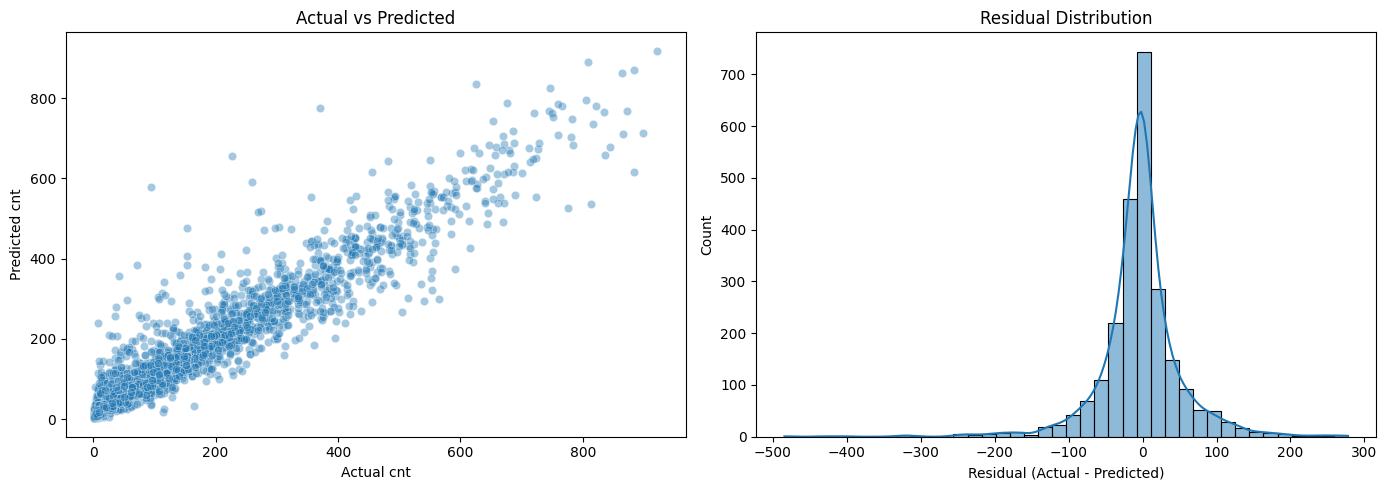

In [13]:
# Diagnostik sederhana: Actual vs Predicted dan distribusi residual
# Hitung ulang prediksi agar cell tetap aman dijalankan setelah kernel restart.
if 'final_model' not in globals():
    raise NameError("final_model belum tersedia. Jalankan cell 'Pilih model final' terlebih dahulu.")

print("=== Grafik Diagnostik untuk Model Final ===")
final_pred = final_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=final_pred, alpha=0.4, ax=axes[0])
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual cnt')
axes[0].set_ylabel('Predicted cnt')

residuals = y_test - final_pred
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

- Pada grafik **Actual vs Predicted**, titik prediksi cenderung mengikuti pola nilai aktual, yang menunjukkan bahwa model final sudah mampu menangkap pola utama pada target (`cnt`).
- Pada grafik **Residual Distribution**, error prediksi (residual) secara umum berpusat di sekitar 0 (nol). Ini menandakan model tidak menunjukkan bias besar ke arah overestimate atau underestimate.
- Meskipun demikian, masih ada penyebaran residual pada beberapa observasi, sehingga prediksi pada kondisi ekstrem tetap perlu diwaspadai.
- Secara keseluruhan, hasil diagnostik mendukung bahwa performa model final cukup baik dan konsisten untuk kebutuhan prediksi demand rental sepeda.

## 4. Conclusion and Recommendation

### 4.1 Conclusion
Berdasarkan tahap **Perbandingan Model Regresi** dan evaluasi **Model Final**, model terbaik untuk memprediksi jumlah penyewaan sepeda (`cnt`) adalah **RandomForest** karena memiliki **RMSE test** paling rendah.

Ringkasan performa Model Final:
- **MAE: 34.8012**
- **RMSE: 56.5181**
- **R-squared: 0.8975**

Makna terhadap bisnis (measurable):
- Nilai **MAE** menunjukkan rata-rata selisih prediksi sekitar **35 unit sepeda** per observasi.
- Nilai **R-squared** menunjukkan model mampu menjelaskan sekitar **89.75%** variasi permintaan (`cnt`).
- Nilai **RMSE** yang lebih tinggi dari MAE menandakan masih ada beberapa error yang relatif besar pada kondisi tertentu.

Kapan Model Final lebih dapat dipercaya:
- Saat kondisi operasional memiliki pola yang mirip dengan data historis (jam, musim, dan cuaca umum).
- Saat tidak terjadi perubahan pola permintaan yang ekstrem dibanding data pelatihan.

Kapan Model Final kurang dapat dipercaya:
- Saat terjadi kondisi ekstrem/kejadian langka yang kurang terwakili pada data historis.
- Saat terjadi perubahan pola demand secara mendadak (**data drift**).

Batasan project:
- Dataset belum memasukkan fitur eksternal penting (misalnya event kota, lokasi stasiun detail, atau cuaca granular).
- Evaluasi masih berbasis train-test split saat ini dan belum mencakup monitoring pasca-deployment secara berkelanjutan.

### 4.2 Recommendation
- Gunakan model sebagai alat bantu perencanaan operasional pada demand normal, bukan sebagai satu-satunya pengambil keputusan.
- Lakukan retraining berkala agar model tetap relevan terhadap pola demand terbaru.
- Tambahkan fitur eksternal (event kota, cuaca lebih detail, lokasi stasiun) untuk meningkatkan akurasi pada kondisi ekstrem.
- Terapkan monitoring produksi untuk **data drift** dan **error drift** dengan threshold yang jelas.
- Definisikan ulang target performa bisnis secara periodik (misalnya batas MAE/RMSE yang diterima tim operasional).

### Appendix: Save Model Artifact

In [14]:

artifact = {
    'model_name': best_model_name,
    'pipeline': final_model,
    'feature_columns': feature_cols,
    'target_column': target_col,
    'metrics': {
        'mae': float(final_mae),
        'rmse': float(final_rmse),
        'r2': float(final_r2)
    }
}

with open('best_bike_sharing_regression_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print("=== Model  Saved ===")
print('Model saved to best_bike_sharing_regression_model.pkl')

=== Model  Saved ===
Model saved to best_bike_sharing_regression_model.pkl


In [ ]:
# from google.colab import files
# files.download('/content/best_bike_sharing_regression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>